# Astrophysical Models

This notebook demonstrates the astrophysical component of `toolscosmo`: empirical models
that connect dark matter halo properties to observable galaxy properties at high redshift.

**Contents**

1. **Star Formation Efficiency (SFE)** — $f_*(M_h, z)$, the fraction of accreted baryons
   converted into stars as a function of halo mass and redshift.
2. **Mass Accretion Rates** — halo mass accretion $\dot{M}(M_h, z)$ under different
   prescriptions (EXP and Hubble-scale).
3. **UV Magnitude – Halo Mass Relation** — how halo mass maps to UV absolute magnitude
   $M_\mathrm{AB}$.
4. **UV Luminosity Functions (UVLFs)** — number density of galaxies per UV magnitude bin,
   compared to HST observations.

The SFE is parameterised as a double power-law in halo mass (Park et al. 2019):
$$f_*(M_h) = \frac{2 f_0}{\left(\frac{M_h}{M_p}\right)^{-\gamma_1} + \left(\frac{M_h}{M_p}\right)^{-\gamma_2}}
\cdot \left[1 + \left(\frac{M_t}{M_h}\right)^{\gamma_3}\right]^{\gamma_4/\gamma_3}$$
with peak efficiency $f_0$ at pivot mass $M_p$, faint-end slope $\gamma_1$,
bright-end slope $\gamma_2$, and low-mass suppression below threshold $M_t$.

Two **mass accretion prescriptions** are compared:
- **EXP** — exponential growth $M(z) \propto e^{-\alpha z}$ (Fakhouri et al. 2010).
- **Hubble-scale** — accretion rate tied to the Hubble time (21cmFAST convention).

---
## 1. Setup

A single `par` object is created here with all cosmological, grid, and SFE parameters
(Park et al. 2019 calibration).  It is reused in every section below.
Sections 1–4 compare two **mass accretion prescriptions**:

- **EXP** — exponential growth $\dot{M} \propto M\,e^{\alpha(z-z_0)}$
  (Fakhouri et al. 2010, default `par.code.MA = 'EXP'`)
- **Hubble-scale** — accretion rate tied to the local Hubble time
  (21cmFAST convention, `par.code.MA = 'HUBBLEscale'`)

Only the accretion-model parameters differ between the two runs;
all SFE and cosmological settings are identical.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import toolscosmo as tcm

plt.rcParams.update({'font.size': 12, 'lines.linewidth': 2})

# ── Single parameter object used throughout ──────────────────────────────
par = tcm.par()
par.file.ps = 'CAMB'

# Cosmology (Planck 2013 ΛCDM)
par.cosmo.Ob = 0.049
par.cosmo.Om = 0.315          # Ωm = Ωdm + Ωb
par.cosmo.s8 = 0.830
par.cosmo.ns = 0.963
par.cosmo.h0 = 0.673

# Grid resolution
par.code.MA    = 'EXP'
par.code.NM    = 100;  par.code.Nz   = 50
par.code.Mmin  = 5e5;  par.code.Mmax = 2e15
par.code.kmin  = 1e-5; par.code.kmax = 5e2
par.code.zmin  = 5.0;  par.code.zmax = 40.0

# EXP accretion parameter (Fakhouri et al. 2010)
par.MA.alpha_EXP = 0.79

# Halo mass function — Sheth-Tormen with tophat filter
par.mf.window = 'tophat';  par.mf.c = 2.5;  par.mf.q = 0.85;  par.mf.p = 0.3

# Star Formation Efficiency — Park et al. 2019
par.lf.f0_sfe    = 0.1;    par.lf.g1_sfe = 0.49;  par.lf.g2_sfe = -0.61
par.lf.g3_sfe    = 5;      par.lf.g4_sfe = -5
par.lf.Mp_sfe    = 2.0e11; par.lf.Mt_sfe = 7e8
par.lf.f0_sfe_nu = -0.1
par.lf.g1_sfe_nu = par.lf.g2_sfe_nu = par.lf.g3_sfe_nu = par.lf.g4_sfe_nu = 0
par.lf.Mp_sfe_nu = par.lf.Mt_sfe_nu = 0

# UV magnitude grid and scatter
par.lf.Muv_min = -23.; par.lf.Muv_max = -8.0; par.lf.NMuv = 20
par.lf.sig_M   = 0.2;  par.lf.eps_sys = 1.0


In [2]:
# Hubble-scale model: deep-copy par and change only MA settings
par_hub           = copy.deepcopy(par)
par_hub.code.MA   = 'HUBBLEscale'
par_hub.MA.t_star = 0.3            # effective star-formation timescale

lf_EXP      = tcm.UVLF(par).UV_luminosity()
lf_21cmfast = tcm.UVLF(par_hub).UV_luminosity()


Using CAMB to estimate linear power spectrum.
sigma_8=0.811
CAMB runtime: 1.97 s
Preparing cosmological solvers...
...done
MA is modelled with the EXP method
Using CAMB to estimate linear power spectrum.
sigma_8=0.811
CAMB runtime: 1.79 s
Preparing cosmological solvers...
...done
MA is modelled with the HUBBLEscale method


---
## 2. Star Formation Efficiency $f_*(M_h, z)$

The SFE sets the stellar mass formed per unit accreted mass. It peaks at the pivot mass
$M_p \sim 10^{11}\,M_\odot$ and is suppressed at both low mass (photo-ionisation feedback)
and high mass (AGN feedback). The two line styles show the two accretion models —
differences in $f_*$ arise because the same star formation prescription is applied to
different accretion histories.

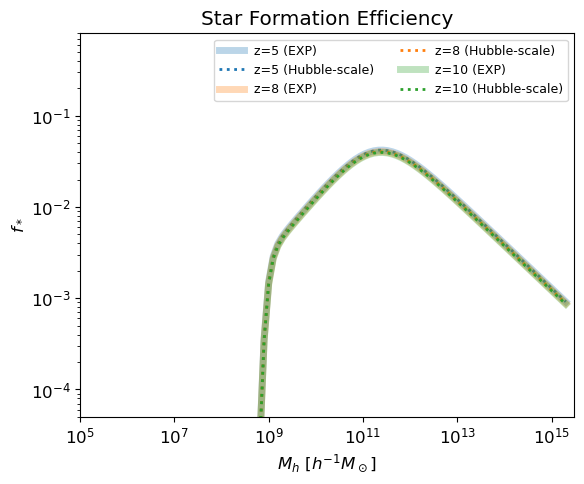

In [3]:
zplot = [5, 8, 10]

fig, ax = plt.subplots(figsize=(6, 5))
for jj, zj in enumerate(zplot):
    z_jdx = np.abs(lf_EXP['z'] - zj).argmin()
    ax.loglog(lf_EXP['m'],      lf_EXP['fstar'][z_jdx, :],
              lw=5, c=f'C{jj}', alpha=0.3, ls='-',  label=f'z={zj} (EXP)')
    ax.loglog(lf_21cmfast['m'], lf_21cmfast['fstar'][z_jdx, :],
              lw=2, c=f'C{jj}', alpha=1.0, ls=':', label=f'z={zj} (Hubble-scale)')
ax.axis([1e5, 3e15, 5e-5, 8e-1])
ax.set_xlabel(r'$M_h$ [$h^{-1}M_\odot$]')
ax.set_ylabel(r'$f_*$')
ax.set_title('Star Formation Efficiency')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout(); plt.show()


---
## 3. Mass Accretion Rates

The left panel shows the total accreted mass $M_\mathrm{accr}(z)$ for halos of different
present-day masses. The right panel shows the instantaneous accretion rate
$\dot{M}_\mathrm{accr}(z)$. The EXP prescription (solid, faded) gives faster early growth
than the Hubble-scale prescription (dotted), leading to differences in star formation
history at high redshift.

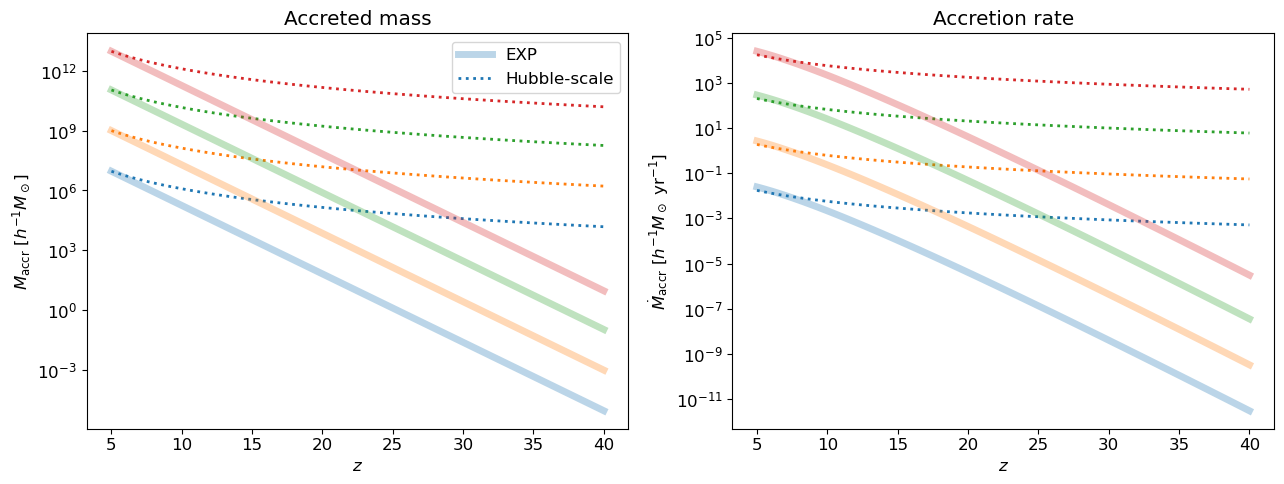

In [4]:
Mplot = [1e7, 1e9, 1e11, 1e13]

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
for jj, mj in enumerate(Mplot):
    m_jdx = np.abs(lf_EXP['m'] - mj).argmin()
    axs[0].semilogy(lf_EXP['z'],      lf_EXP['M_accr'][:, m_jdx],
                    lw=5, alpha=0.3, c=f'C{jj}', ls='-',
                    label='EXP' if jj == 0 else None)
    axs[0].semilogy(lf_21cmfast['z'], lf_21cmfast['M_accr'][:, m_jdx],
                    lw=2, alpha=1.0, c=f'C{jj}', ls=':',
                    label='Hubble-scale' if jj == 0 else None)
    axs[1].semilogy(lf_EXP['z'],      lf_EXP['dMdt_accr'][:, m_jdx],
                    lw=5, alpha=0.3, c=f'C{jj}', ls='-')
    axs[1].semilogy(lf_21cmfast['z'], lf_21cmfast['dMdt_accr'][:, m_jdx],
                    lw=2, alpha=1.0, c=f'C{jj}', ls=':')
axs[0].legend()
axs[0].set_xlabel('$z$'); axs[0].set_ylabel(r'$M_\mathrm{accr}$ [$h^{-1}M_\odot$]')
axs[0].set_title('Accreted mass')
axs[1].set_xlabel('$z$'); axs[1].set_ylabel(r'$\dot{M}_\mathrm{accr}$ [$h^{-1}M_\odot$ yr$^{-1}$]')
axs[1].set_title('Accretion rate')
plt.tight_layout(); plt.show()


---
## 4. UV Magnitude – Halo Mass Relation

The UV absolute magnitude $M_\mathrm{AB}$ is computed from the star formation rate via the
UV luminosity conversion factor $\kappa_\mathrm{UV}$. The left panel shows $M_\mathrm{AB}(M_h)$
at several redshifts; the right panel shows the ratio between the two accretion prescriptions,
which propagates the accretion-rate difference into the observable UV magnitude.

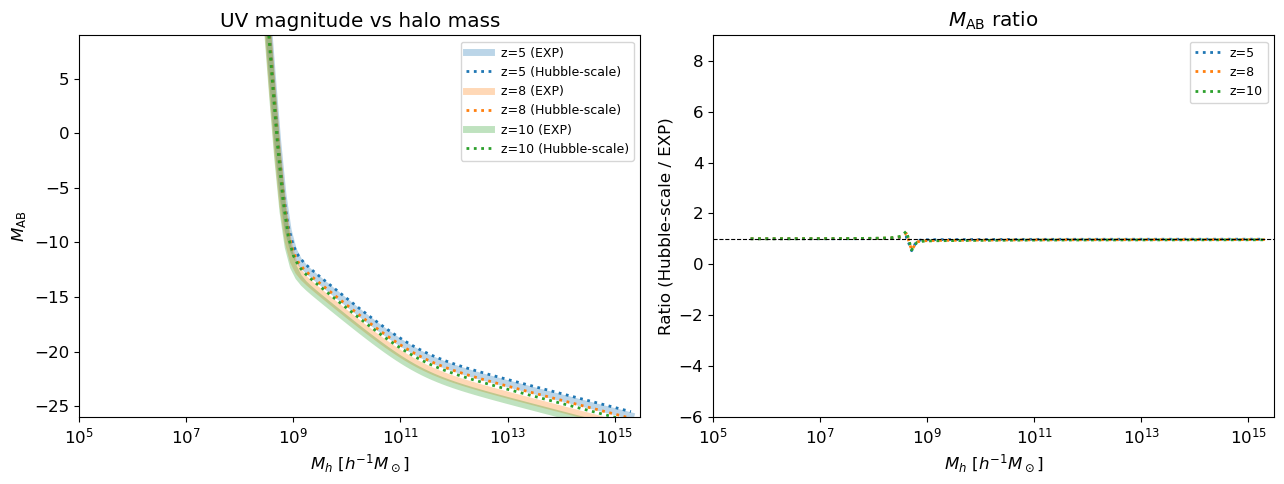

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
for jj, zj in enumerate(zplot):
    z_jdx = np.abs(lf_EXP['z'] - zj).argmin()
    axs[0].semilogx(lf_EXP['m'],      lf_EXP['M_AB'][z_jdx, :],
                    lw=5, c=f'C{jj}', alpha=0.3, ls='-',  label=f'z={zj} (EXP)')
    axs[0].semilogx(lf_21cmfast['m'], lf_21cmfast['M_AB'][z_jdx, :],
                    lw=2, c=f'C{jj}', alpha=1.0, ls=':', label=f'z={zj} (Hubble-scale)')
    axs[1].semilogx(lf_EXP['m'],
                    lf_21cmfast['M_AB'][z_jdx, :] / lf_EXP['M_AB'][z_jdx, :],
                    lw=2, c=f'C{jj}', ls=':', label=f'z={zj}')
axs[0].legend(fontsize=9)
axs[0].axis([1e5, 3e15, -26, 9])
axs[0].set_xlabel(r'$M_h$ [$h^{-1}M_\odot$]'); axs[0].set_ylabel(r'$M_\mathrm{AB}$')
axs[0].set_title('UV magnitude vs halo mass')
axs[1].axhline(1, color='k', lw=0.8, ls='--')
axs[1].axis([1e5, 3e15, -6, 9])
axs[1].set_xlabel(r'$M_h$ [$h^{-1}M_\odot$]'); axs[1].set_ylabel('Ratio (Hubble-scale / EXP)')
axs[1].set_title(r'$M_\mathrm{AB}$ ratio')
axs[1].legend(fontsize=9)
plt.tight_layout(); plt.show()


---
## 5. UV Luminosity Functions compared to observations

The UVLF $\phi(M_\mathrm{UV})$ is computed by convolving the halo mass function (HMF) with
the $M_h \to M_\mathrm{UV}$ mapping, including a log-normal scatter $\sigma_M$
at fixed halo mass.  We first inspect the HMF itself (§5a), then compare the predicted UVLF
to HST and JWST observations loaded from `corecon` (§5b).

Both the HMF and UVLF use the same `par` defined in §1 — no additional setup needed.


In [6]:
# HMF and UVLF — par already defined in §1; out_lf reuses the EXP run
hmf    = tcm.mass_fct(par)
out_lf = lf_EXP
print('z grid:', out_lf['z'][[0, -1]], '  n_z =', len(out_lf['z']))


z grid: [ 5. 40.]   n_z = 50


### 5a. Halo Mass Function

The HMF $dn/d\ln M$ gives the comoving number density of halos per logarithmic mass bin.
Here we use the Sheth-Tormen form with tophat filter.  This is the key ingredient entering
the UVLF integral.


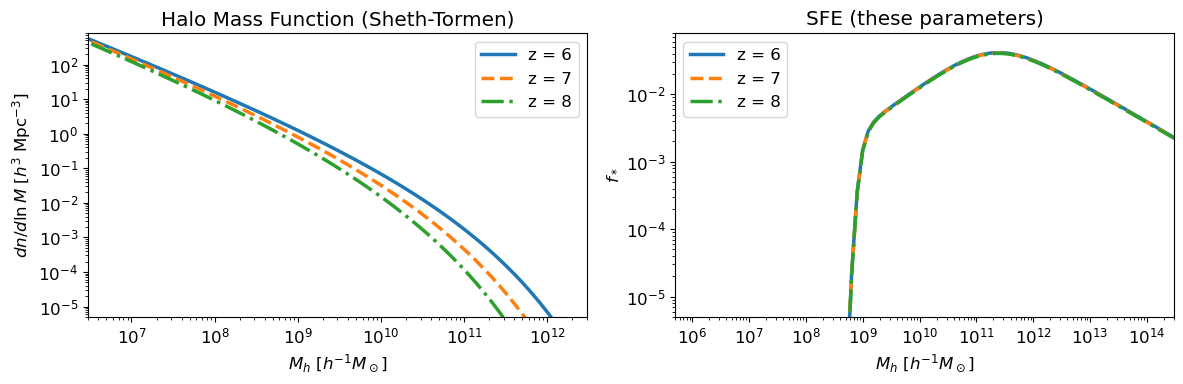

In [7]:
z_plot = [6, 7, 8]
lstyles = ['-', '--', '-.']

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
for ii, zi in enumerate(z_plot):
    z_idx = np.abs(hmf['z'] - zi).argmin()
    ax.loglog(hmf['m'], hmf['dndlnm'][z_idx, :],
              lw=2.5, ls=lstyles[ii], label=f'z = {zi}')
ax.legend()
ax.axis([3e6, 3e12, 5e-6, 8e2])
ax.set_xlabel(r'$M_h$ [$h^{-1}M_\odot$]')
ax.set_ylabel(r'$dn/d\ln M$ [$h^3$ Mpc$^{-3}$]')
ax.set_title('Halo Mass Function (Sheth-Tormen)')

ax = axs[1]
fstars = tcm.fstar(hmf['z'], hmf['m'], 'lf', par)
for ii, zi in enumerate(z_plot):
    z_idx = np.abs(hmf['z'] - zi).argmin()
    ax.loglog(hmf['m'], fstars[z_idx, :],
              lw=2.5, ls=lstyles[ii], label=f'z = {zi}')
ax.legend()
ax.axis([5e5, 3e14, 5e-6, 8e-2])
ax.set_xlabel(r'$M_h$ [$h^{-1}M_\odot$]')
ax.set_ylabel(r'$f_*$')
ax.set_title('SFE (these parameters)')
plt.tight_layout(); plt.show()


### 5b. UVLF vs observations

Observational data are loaded via `toolscosmo.load_uvlf_data(source='corecon')`,
which fetches all 36 UVLF compilations from the
[`corecon`](https://github.com/qyx268/corecon) package (install once with
`pip install corecon`) and caches them locally as
`input_data/uvlf_corecon.csv`.  The data include HST and JWST studies from
Bouwens, Harikane, Donnan, Finkelstein, Adams, and many others.
Upper limits are shown as downward-pointing triangles.


36 studies, 591 data points


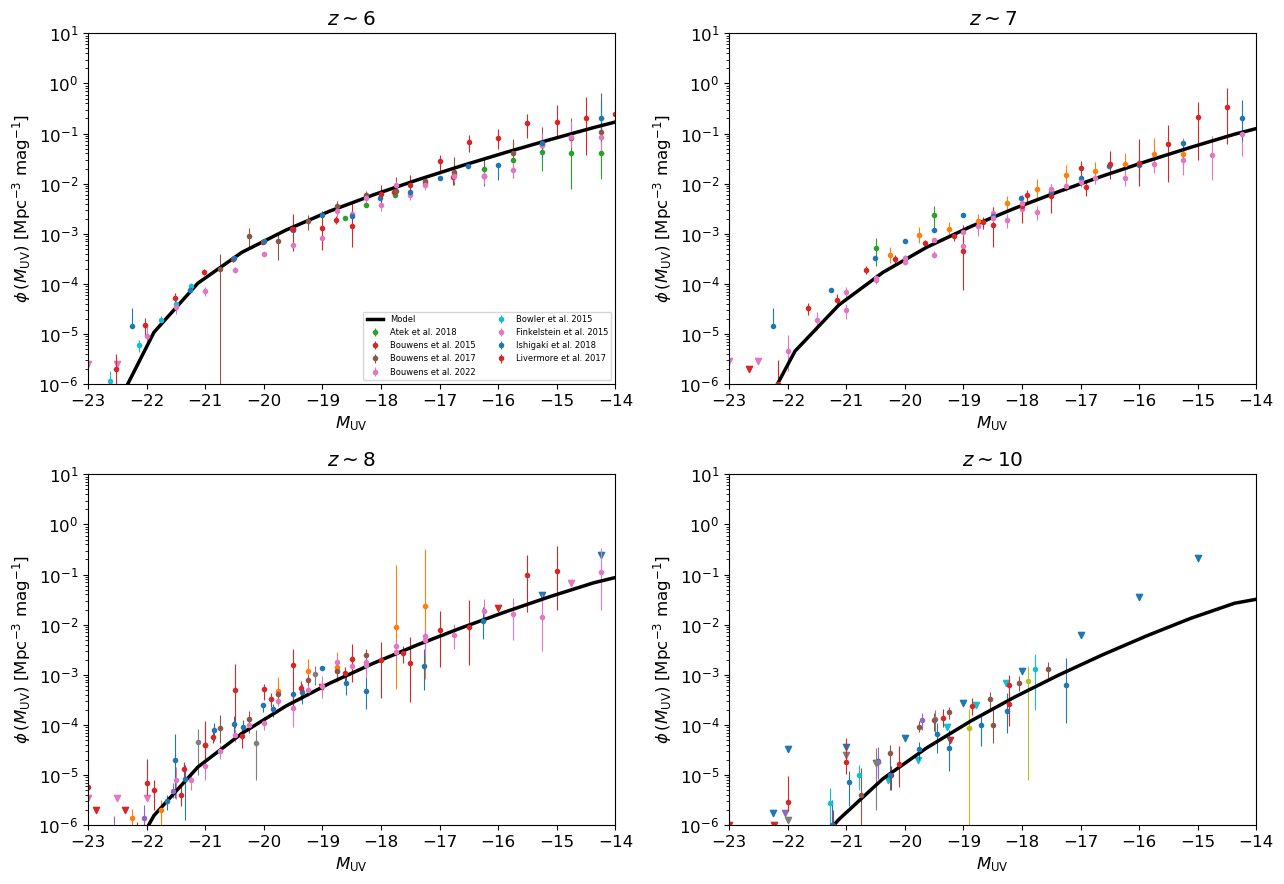

In [8]:
# Load all UVLF observations from corecon (downloads + caches on first call)
uvlf_obs = tcm.load_uvlf_data(source='corecon')
print(f"{len(uvlf_obs['reference'].unique())} studies, {len(uvlf_obs)} data points")

z_bins = [6, 7, 8, 10]
fig, axs = plt.subplots(2, 2, figsize=(13, 9))
axs = axs.flatten()

# Use a colour cycle large enough for many references
import itertools
colour_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
ref_colours  = {ref: next(colour_cycle)
                for ref in sorted(uvlf_obs['reference'].unique())}

for j, zj in enumerate(z_bins):
    ax = axs[j]
    ax.set_title(f'$z\\sim {zj}$')

    # observations near this redshift
    df_z = uvlf_obs[abs(uvlf_obs['z'] - zj) <= 0.5]

    for ref, grp in df_z.groupby('reference'):
        col  = ref_colours[ref]
        det  = grp[~grp['upper_lim']]
        ulim = grp[grp['upper_lim']]

        if len(det):
            phi    = 10 ** det['log_phi'].values
            e_up   = 10 ** (det['log_phi'].values + det['err_up'].values)   - phi
            e_dn   = phi - 10 ** (det['log_phi'].values - det['err_down'].values)
            ax.errorbar(det['M_UV'].values, phi,
                        yerr=[e_dn, e_up], fmt='o', ms=3,
                        color=col, elinewidth=0.8,
                        label=ref if j == 0 else None)
        if len(ulim):
            ax.scatter(ulim['M_UV'].values, 10 ** ulim['log_phi'].values,
                       marker='v', s=20, color=col)

    # model
    z_jdx = abs(out_lf['z'] - zj).argmin()
    ax.plot(out_lf['uvlf']['Muv_mean'], out_lf['uvlf']['phi_uv'][z_jdx, :],
            lw=2.5, color='k', label='Model' if j == 0 else None)

    ax.set_yscale('log')
    ax.axis([-23, -14, 1e-6, 1e1])
    ax.set_xlabel(r'$M_{\rm UV}$')
    ax.set_ylabel(r'$\phi\,(M_{\rm UV})$ [Mpc$^{-3}$ mag$^{-1}$]')

axs[0].legend(fontsize=6, loc='lower right', ncol=2)
plt.tight_layout()
plt.show()
